<a href="https://colab.research.google.com/github/karogendo-droid/BigDataClass-ACE-2025/blob/main/Copy_of_Getting_started_with_google_colab_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Machine Learning-Based Prediction of Malaria Complication Risk Using Clinical Symptom Profiles: A Comparative Analysis of Logistic Regression, Decision Tree, and Random Forest Classifiers**

##**Upload Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

print("✅ File uploaded successfully!")
print("Uploaded file name:", list(uploaded.keys())[0])

Saving Malaria_Dataset.csv to Malaria_Dataset.csv
✅ File uploaded successfully!
Uploaded file name: Malaria_Dataset.csv


##**Install extra libraries**

In [2]:
!pip install imbalanced-learn --quiet

print("✅ Libraries installed!")

✅ Libraries installed!


##**Import all the libraries I will use**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE     # For fixing class imbalance

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


##**Load the dataset**

In [6]:
df = pd.read_csv('Malaria_Dataset.csv')

print("✅ Dataset loaded!")
print(f"📊 The dataset has {df.shape[0]} rows (patients) and {df.shape[1]} columns (features)")

✅ Dataset loaded!
📊 The dataset has 1622 rows (patients) and 19 columns (features)


##**Data Cleaning**

Duplicates removed                 : 0
Age outliers removed               : 0
Binary column issues found         : 0
Text columns standardised          : ['Sex', 'Residence_Area']
Invalid Target values removed      : 0
Missing values remaining           : 0


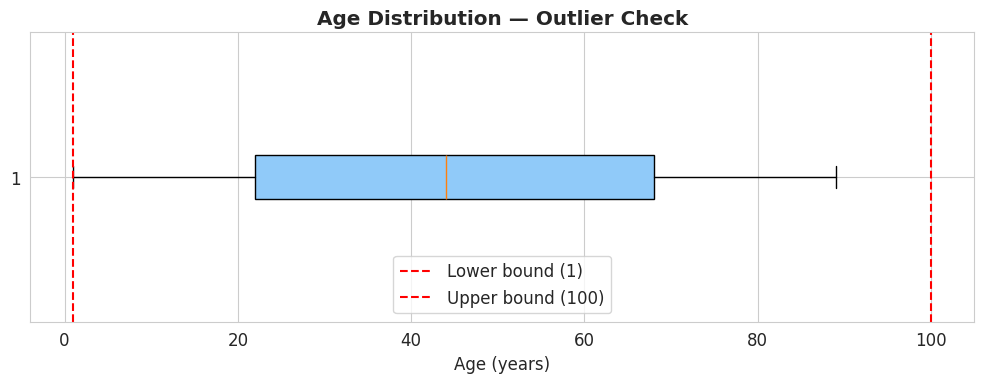


         DATA CLEANING SUMMARY REPORT
  Total rows after cleaning      : 1622
  Total columns                  : 19
  Duplicate rows removed         : 0
  Age outliers removed           : 0
  Binary columns validated       : 11
  Text columns standardised      : 2
  Missing values remaining       : 0

✅ Dataset is clean and ready for analysis!


In [7]:
import matplotlib.pyplot as plt

symptom_cols = ['Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise',
                'Dizziness', 'Vomiting', 'Confusion', 'Backache',
                'Chest_Pain', 'Coughing', 'Joint_Pain']
text_cols = ['Sex', 'Residence_Area']

# ---------- 1. DUPLICATES ----------
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
print(f"{'Duplicates removed':<35}: {duplicates}")

# ---------- 2. AGE OUTLIERS ----------
age_outliers = df[(df['Age'] < 1) | (df['Age'] > 100)]
if len(age_outliers) > 0:
    df = df[df['Age'].between(1, 100)]
print(f"{'Age outliers removed':<35}: {len(age_outliers)}")

# ---------- 3. VALIDATE BINARY SYMPTOM COLUMNS ----------
binary_issues = {}
for col in symptom_cols:
    invalid = [v for v in df[col].unique() if v not in [0, 1]]
    if invalid:
        binary_issues[col] = invalid
print(f"{'Binary column issues found':<35}: {len(binary_issues)}")
if binary_issues:
    for col, vals in binary_issues.items():
        print(f"   ⚠️  {col}: {vals}")

# ---------- 4. STANDARDISE TEXT COLUMNS ----------
for col in text_cols:
    df[col] = df[col].str.strip().str.title()
print(f"{'Text columns standardised':<35}: {text_cols}")

# ---------- 5. VALIDATE TARGET COLUMN ----------
invalid_target = [v for v in df['Target'].unique() if v not in [0, 1]]
if invalid_target:
    df = df[df['Target'].isin([0, 1])]
print(f"{'Invalid Target values removed':<35}: {len(invalid_target)}")

# ---------- 6. MISSING VALUES CHECK ----------
missing_after = df.isnull().sum().sum()
print(f"{'Missing values remaining':<35}: {missing_after}")

# ---------- 7. AGE OUTLIER BOXPLOT ----------
plt.figure(figsize=(10, 4))
plt.boxplot(df['Age'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#90CAF9'))
plt.axvline(x=1,   color='red', linestyle='--', label='Lower bound (1)')
plt.axvline(x=100, color='red', linestyle='--', label='Upper bound (100)')
plt.title('Age Distribution — Outlier Check', fontweight='bold')
plt.xlabel('Age (years)')
plt.legend()
plt.tight_layout()
plt.savefig('fig0a_age_outlier_check.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------- 8. SUMMARY REPORT ----------
print("\n" + "=" * 60)
print("         DATA CLEANING SUMMARY REPORT")
print("=" * 60)
print(f"  Total rows after cleaning      : {df.shape[0]}")
print(f"  Total columns                  : {df.shape[1]}")
print(f"  Duplicate rows removed         : {duplicates}")
print(f"  Age outliers removed           : {len(age_outliers)}")
print(f"  Binary columns validated       : {len(symptom_cols)}")
print(f"  Text columns standardised      : {len(text_cols)}")
print(f"  Missing values remaining       : {missing_after}")
print("=" * 60)
print("\n✅ Dataset is clean and ready for analysis!")

##**Dataset Preview**

In [8]:
print("📋 First 5 rows of the dataset:")
df.head()

📋 First 5 rows of the dataset:


,IP_Number,Age,Sex,Residence_Area,DOA,Discharge_Date,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Diagnosis_Type,Target
0,14xxxx31,52,Female,Mangalore,31/10/2015 20:42,05/11/2015 05:16,0,0,0,1,0,0,0,1,0,0,0,Mixed Malaria Infection,0
1,28xxxx34,75,Female,Shimoga,03/02/2015 23:28,13/02/2015 19:27,1,0,1,1,1,0,1,0,1,1,1,Mixed Malaria Infection,1
2,96xxxx43,30,Female,Mangalore,15/11/2019 12:31,19/11/2019 14:31,1,1,1,1,0,0,1,1,1,0,1,Mixed Malaria Infection,1
3,49xxxx87,89,Female,Mangalore,17/05/2017 17:50,23/05/2017 13:22,0,0,0,0,1,1,1,1,1,0,1,Plasmodium vivax Malaria without complication,0
4,48xxxx10,62,Male,Shimoga,26/06/2015 15:29,27/06/2015 23:35,0,1,0,1,0,1,1,0,0,0,0,Plasmodium falciparum Malaria without complica...,1


##**Check column names and data types**

In [9]:
print("📌 Column names and their data types:")
print(df.dtypes)

📌 Column names and their data types:
IP_Number               object
Age                      int64
Sex                     object
Residence_Area          object
DOA                     object
Discharge_Date          object
Fever                    int64
Headache                 int64
Abdominal_Pain           int64
General_Body_Malaise     int64
Dizziness                int64
Vomiting                 int64
Confusion                int64
Backache                 int64
Chest_Pain               int64
Coughing                 int64
Joint_Pain               int64
Diagnosis_Type          object
Target                   int64
dtype: object


##**Statistical summary of numeric columns**

In [10]:
print("📈 Statistical summary:")
df.describe().round(2)

📈 Statistical summary:


,Age,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Target
count,1622.00,1622.00,1622.00,1622.0,1622.00,1622.0,1622.0,1622.00,1622.00,1622.0,1622.00,1622.00,1622.00
mean,44.71,0.47,0.51,0.5,0.48,0.5,0.5,0.48,0.51,0.5,0.48,0.51,0.72
std,26.03,0.50,0.50,0.5,0.50,0.5,0.5,0.50,0.50,0.5,0.50,0.50,0.45
min,1.00,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00
25%,22.00,0.00,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.0,0.00,0.00,0.00
50%,44.00,0.00,1.00,0.0,0.00,1.0,0.5,0.00,1.00,1.0,0.00,1.00,1.00
75%,68.00,1.00,1.00,1.0,1.00,1.0,1.0,1.00,1.00,1.0,1.00,1.00,1.00
max,89.00,1.00,1.00,1.0,1.00,1.0,1.0,1.00,1.00,1.0,1.00,1.00,1.00


##**Check the target variable**

In [12]:
print("Target variable distribution:")
counts = df['Target'].value_counts()
print(counts)
print(f"\nPercentage:")
print(df['Target'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

print("\n Interpretation:")
print(f"  - {counts[0]} patients ({counts[0]/len(df)*100:.1f}%) had UNCOMPLICATED malaria (Target=0)")
print(f"  - {counts[1]} patients ({counts[1]/len(df)*100:.1f}%) had COMPLICATED malaria (Target=1)")
print("\n Note: The classes are imbalanced (unequal). We will fix this later using SMOTE.")

Target variable distribution:
Target
1    1167
0     455
Name: count, dtype: int64

Percentage:
Target
1    71.9%
0    28.1%
Name: proportion, dtype: object

 Interpretation:
  - 455 patients (28.1%) had UNCOMPLICATED malaria (Target=0)
  - 1167 patients (71.9%) had COMPLICATED malaria (Target=1)

 Note: The classes are imbalanced (unequal). We will fix this later using SMOTE.


##**Symptom Prevalence**

In [14]:
symptom_cols = ['Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise',
                'Dizziness', 'Vomiting', 'Confusion', 'Backache',
                'Chest_Pain', 'Coughing', 'Joint_Pain']

print("Symptom prevalence (% of patients who had each symptom):")
symptom_prev = df[symptom_cols].mean().mul(100).round(1).sort_values(ascending=False)
for symptom, pct in symptom_prev.items():
    print(f"  {symptom:<25}: {pct}%")

Symptom prevalence (% of patients who had each symptom):
  Joint_Pain               : 51.2%
  Backache                 : 51.0%
  Headache                 : 50.7%
  Dizziness                : 50.4%
  Chest_Pain               : 50.1%
  Vomiting                 : 50.0%
  Abdominal_Pain           : 49.7%
  Coughing                 : 48.4%
  Confusion                : 48.0%
  General_Body_Malaise     : 47.9%
  Fever                    : 47.5%


#**DATA VISUALISATION**

##**Target class distribution**

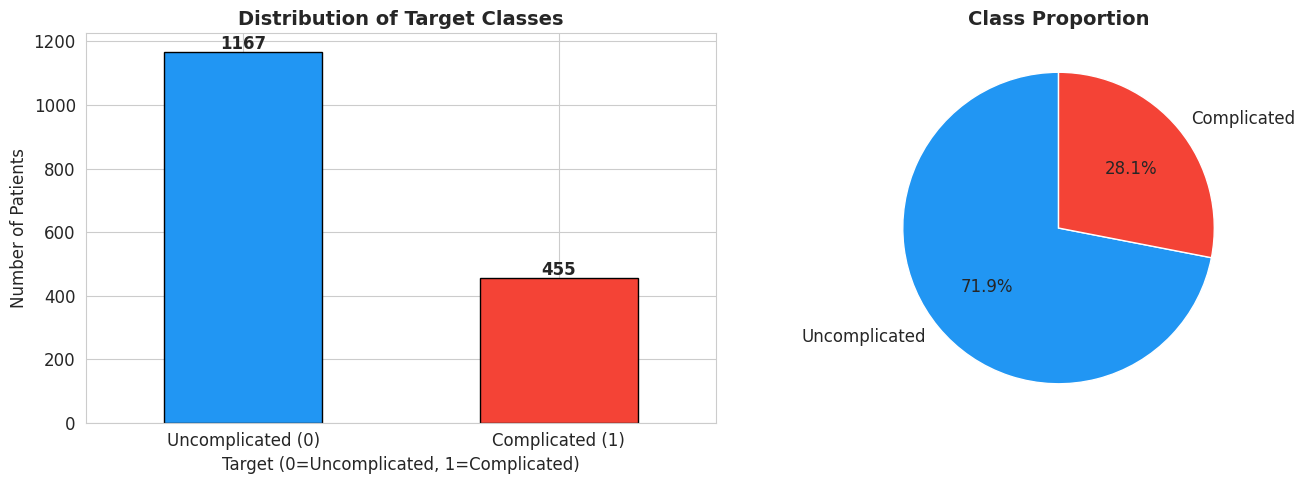

💾 Chart saved as 'fig1_target_distribution.png'


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2196F3', '#F44336']
df['Target'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Distribution of Target Classes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Target (0=Uncomplicated, 1=Complicated)')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticklabels(['Uncomplicated (0)', 'Complicated (1)'], rotation=0)
for i, v in enumerate(df['Target'].value_counts()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
df['Target'].value_counts().plot(kind='pie', ax=axes[1], colors=colors,
                                   autopct='%1.1f%%', startangle=90,
                                   labels=['Uncomplicated', 'Complicated'])
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Chart saved as 'fig1_target_distribution.png'")

##**Symptom prevalence by complication status**

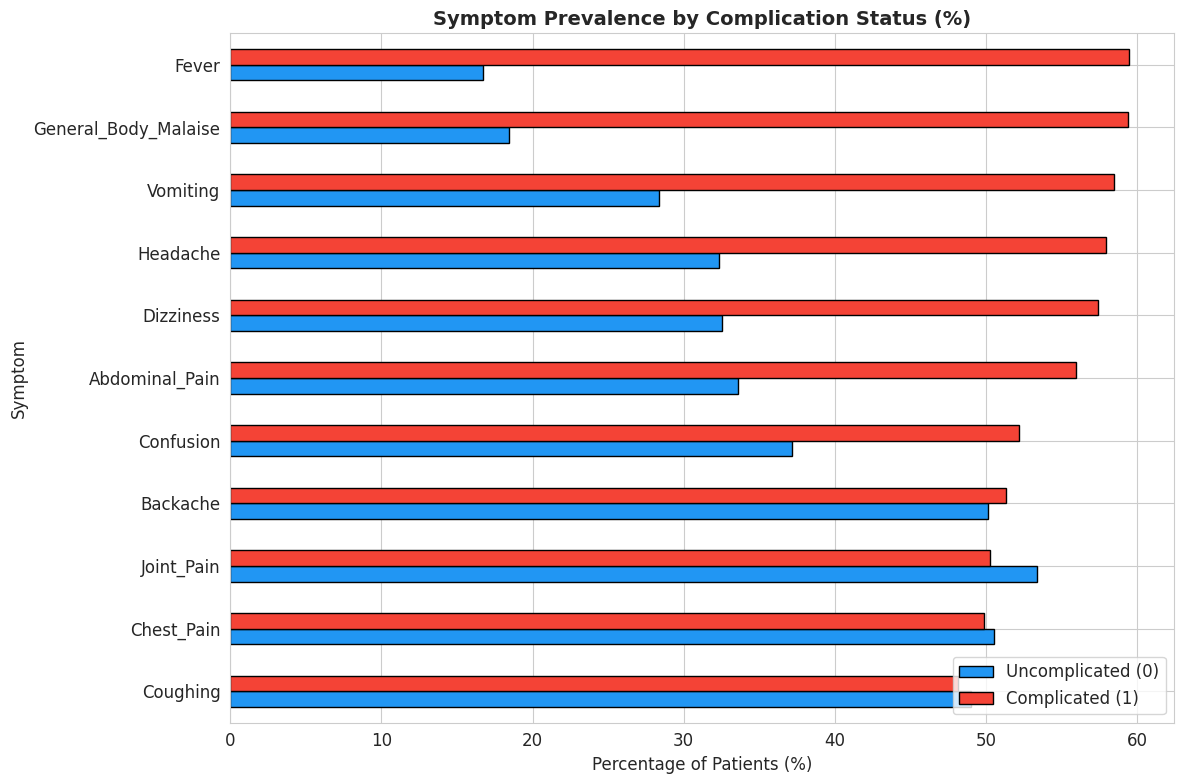

Chart saved as 'fig2_symptoms_by_target.png'


In [17]:
symptom_by_target = df.groupby('Target')[symptom_cols].mean().mul(100).T
symptom_by_target.columns = ['Uncomplicated (0)', 'Complicated (1)']
symptom_by_target = symptom_by_target.sort_values('Complicated (1)', ascending=True)

symptom_by_target.plot(kind='barh', figsize=(12, 8), color=['#2196F3', '#F44336'],
                        edgecolor='black')
plt.title('Symptom Prevalence by Complication Status (%)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Patients (%)')
plt.ylabel('Symptom')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig2_symptoms_by_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'fig2_symptoms_by_target.png'")

##**Sex and Residence Area breakdown**

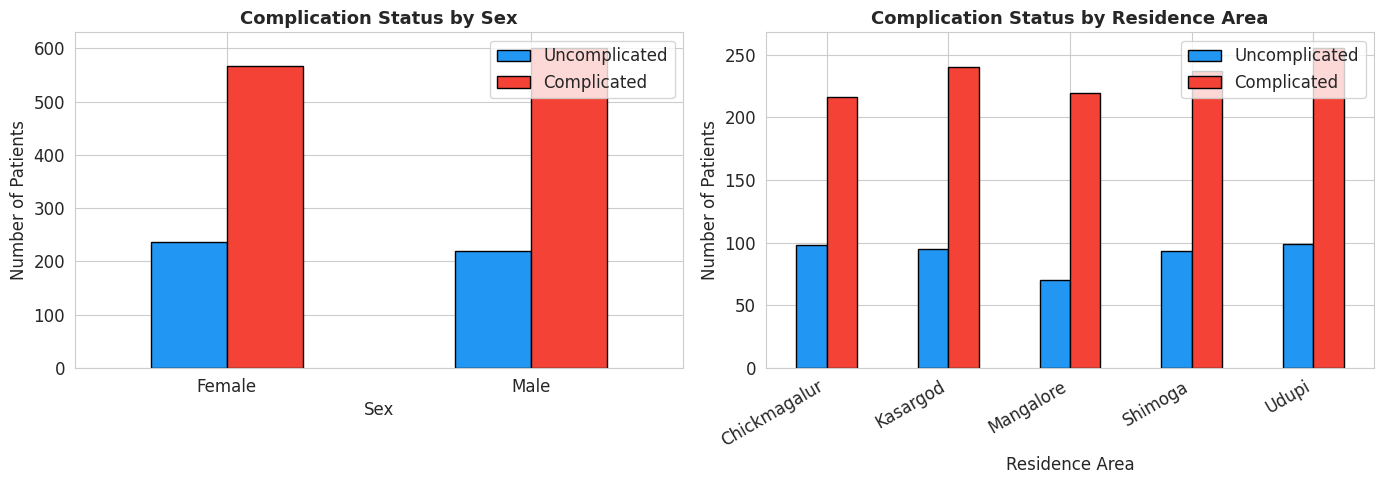

Chart saved as 'fig4_demographics.png'


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex by Target
sex_target = df.groupby(['Sex', 'Target']).size().unstack()
sex_target.columns = ['Uncomplicated', 'Complicated']
sex_target.plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Complication Status by Sex', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Number of Patients')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend()

# Residence Area by Target
area_target = df.groupby(['Residence_Area', 'Target']).size().unstack()
area_target.columns = ['Uncomplicated', 'Complicated']
area_target.plot(kind='bar', ax=axes[1], color=['#2196F3', '#F44336'], edgecolor='black')
axes[1].set_title('Complication Status by Residence Area', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residence Area')
axes[1].set_ylabel('Number of Patients')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig4_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'fig4_demographics.png'")

##**Correlation heatmap**

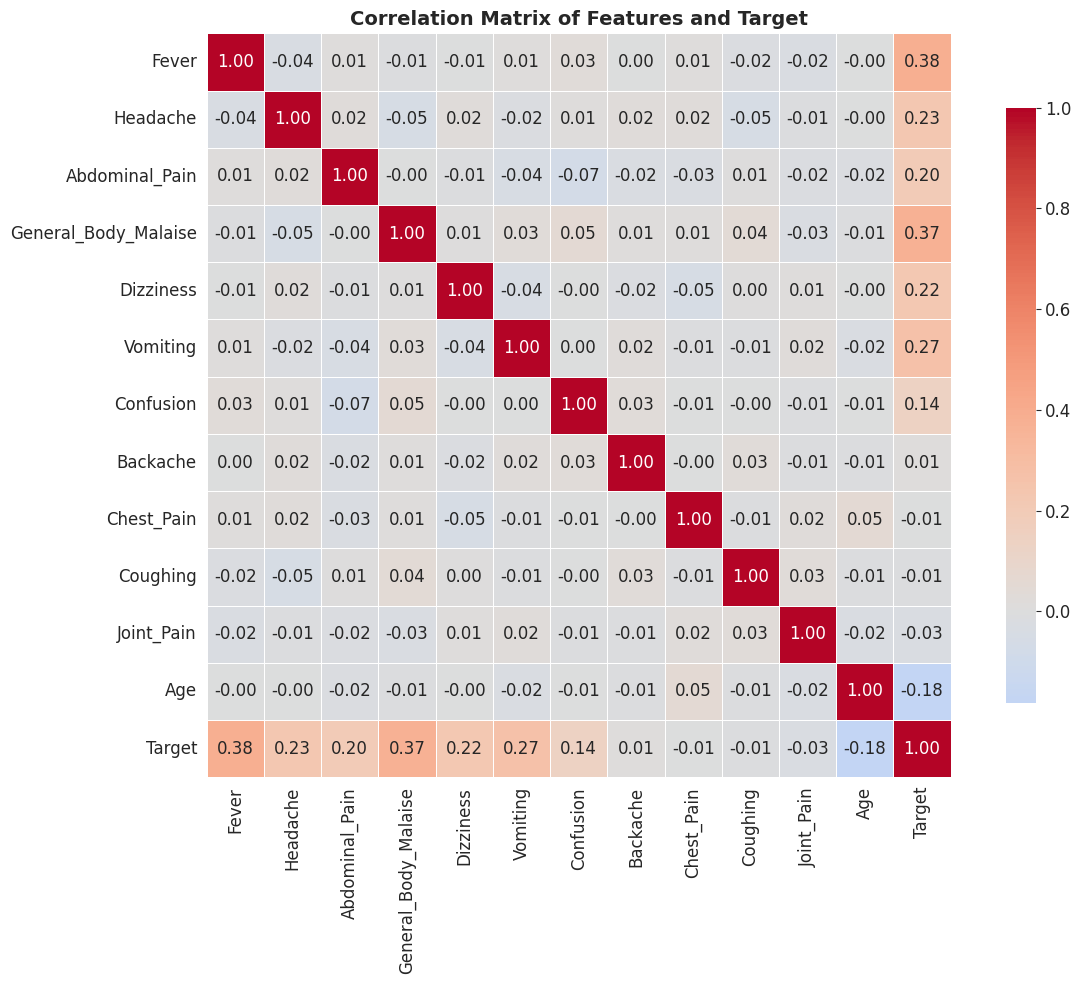

Chart saved as 'fig5_correlation_heatmap.png'

 Values close to +1 or -1 = strong relationship with Target


In [19]:
numeric_cols = symptom_cols + ['Age', 'Target']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Show only lower half

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Features and Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as 'fig5_correlation_heatmap.png'")
print("\n Values close to +1 or -1 = strong relationship with Target")

#**Preparing Data For Machine Learning**

##**Remove columns not useful for prediction**

In [20]:
cols_to_drop = ['IP_Number', 'DOA', 'Discharge_Date', 'Diagnosis_Type']
df_clean = df.drop(columns=cols_to_drop)

print("Dropped columns:", cols_to_drop)
print(f"\nRemaining columns ({len(df_clean.columns)} total):")
print(df_clean.columns.tolist())

Dropped columns: ['IP_Number', 'DOA', 'Discharge_Date', 'Diagnosis_Type']

Remaining columns (15 total):
['Age', 'Sex', 'Residence_Area', 'Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise', 'Dizziness', 'Vomiting', 'Confusion', 'Backache', 'Chest_Pain', 'Coughing', 'Joint_Pain', 'Target']


##**Encode text columns into numbers**

In [22]:
le = LabelEncoder()

# Encode Sex: Female=0, Male=1
df_clean['Sex'] = le.fit_transform(df_clean['Sex'])
print("Sex encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Encode Residence_Area
df_clean['Residence_Area'] = le.fit_transform(df_clean['Residence_Area'])
print("Residence_Area encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

print("\n Text columns encoded into numbers!")
df_clean.head(10)

Sex encoding: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}
Residence_Area encoding: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4)}

 Text columns encoded into numbers!


,Age,Sex,Residence_Area,Fever,Headache,Abdominal_Pain,General_Body_Malaise,Dizziness,Vomiting,Confusion,Backache,Chest_Pain,Coughing,Joint_Pain,Target
0,52,0,2,0,0,0,1,0,0,0,1,0,0,0,0
1,75,0,3,1,0,1,1,1,0,1,0,1,1,1,1
2,30,0,2,1,1,1,1,0,0,1,1,1,0,1,1
3,89,0,2,0,0,0,0,1,1,1,1,1,0,1,0
4,62,1,3,0,1,0,1,0,1,1,0,0,0,0,1
5,7,0,3,0,0,0,1,1,0,1,1,1,1,0,1
6,53,0,0,1,1,1,0,1,0,1,0,1,0,0,1
7,78,0,4,0,1,1,1,1,1,1,1,1,1,1,1
8,54,1,0,0,0,1,1,1,1,1,1,1,1,0,1
9,48,1,2,0,1,1,0,1,0,1,1,0,1,0,1


##**Separate Features (X) from Target (y)**

In [23]:
X = df_clean.drop(columns=['Target'])  # Everything except Target
y = df_clean['Target']                 # Only the Target column

print(f" Features (X): {X.shape[1]} columns, {X.shape[0]} rows")
print(f" Target (y): {y.shape[0]} values")
print(f"\nFeature columns used for prediction:")
print(X.columns.tolist())

 Features (X): 14 columns, 1622 rows
 Target (y): 1622 values

Feature columns used for prediction:
['Age', 'Sex', 'Residence_Area', 'Fever', 'Headache', 'Abdominal_Pain', 'General_Body_Malaise', 'Dizziness', 'Vomiting', 'Confusion', 'Backache', 'Chest_Pain', 'Coughing', 'Joint_Pain']


##**Split into Training and Testing sets**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,          # 20% for testing
    random_state=42,        # For reproducibility
    stratify=y              # Keeps same class ratio in both sets
)

print(" Data split complete!")
print(f"   Training set: {X_train.shape[0]} patients ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Testing set:  {X_test.shape[0]} patients ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Training target distribution:")
print(f"   Uncomplicated: {sum(y_train==0)} | Complicated: {sum(y_train==1)}")

 Data split complete!
   Training set: 1297 patients (80%)
   Testing set:  325 patients (20%)

   Training target distribution:
   Uncomplicated: 364 | Complicated: 933


##**Apply SMOTE to fix class imbalance**

In [27]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(" SMOTE applied!")
print(f"\nBEFORE SMOTE (training set):")
print(f"  Uncomplicated (0): {sum(y_train==0)}")
print(f"  Complicated   (1): {sum(y_train==1)}")
print(f"\nAFTER SMOTE (balanced training set):")
print(f"  Uncomplicated (0): {sum(y_train_balanced==0)}")
print(f"  Complicated   (1): {sum(y_train_balanced==1)}")

 SMOTE applied!

BEFORE SMOTE (training set):
  Uncomplicated (0): 364
  Complicated   (1): 933

AFTER SMOTE (balanced training set):
  Uncomplicated (0): 933
  Complicated   (1): 933


##**Scaling Features**

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)  # Learn scale from training data
X_test_scaled  = scaler.transform(X_test)                # Apply same scale to test data

print("Feature scaling complete!")

Feature scaling complete!


#**Building the Machine Learning Models**

##Train Model 1: Logistic Regression

In [30]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_balanced)

print("Logistic Regression model trained!")

Logistic Regression model trained!


##Train Model 2: Decision Tree

In [33]:
#max_depth=5 prevents the tree from becoming too complex
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)

print(" Decision Tree model trained!")

 Decision Tree model trained!


##Train Model 3: Random Forest

In [34]:
#n_estimators=100 means we build 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

print(" Random Forest model trained! (100 trees built)")

 Random Forest model trained! (100 trees built)


#**Models Evaluation**

In [35]:
# Evaluate all three models and collect results
models = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'Decision Tree':       (dt_model, X_test),
    'Random Forest':       (rf_model, X_test)
}

results = {}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        'Accuracy':  acc,
        'Precision': report['weighted avg']['precision'],
        'Recall':    report['weighted avg']['recall'],
        'F1-Score':  report['weighted avg']['f1-score'],
        'AUC-ROC':   auc,
        'y_pred':    y_pred,
        'y_prob':    y_prob
    }

print(" All models evaluated!\n")
print("=" * 65)
print(f"{'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("=" * 65)
for name, r in results.items():
    print(f"{name:<25} {r['Accuracy']:>9.4f} {r['Precision']:>10.4f} {r['Recall']:>8.4f} {r['F1-Score']:>8.4f} {r['AUC-ROC']:>8.4f}")
print("=" * 65)

 All models evaluated!

Model                      Accuracy  Precision   Recall       F1      AUC
Logistic Regression          0.9477     0.9475   0.9477   0.9470   0.9760
Decision Tree                0.8462     0.8484   0.8462   0.8471   0.9005
Random Forest                0.9538     0.9542   0.9538   0.9531   0.9890


##Detailed classification reports

In [36]:
for name, (model, X_eval) in models.items():
    y_pred = results[name]['y_pred']
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Uncomplicated (0)', 'Complicated (1)']))


  Logistic Regression
                   precision    recall  f1-score   support

Uncomplicated (0)       0.94      0.87      0.90        91
  Complicated (1)       0.95      0.98      0.96       234

         accuracy                           0.95       325
        macro avg       0.95      0.92      0.93       325
     weighted avg       0.95      0.95      0.95       325


  Decision Tree
                   precision    recall  f1-score   support

Uncomplicated (0)       0.72      0.75      0.73        91
  Complicated (1)       0.90      0.88      0.89       234

         accuracy                           0.85       325
        macro avg       0.81      0.82      0.81       325
     weighted avg       0.85      0.85      0.85       325


  Random Forest
                   precision    recall  f1-score   support

Uncomplicated (0)       0.96      0.87      0.91        91
  Complicated (1)       0.95      0.99      0.97       234

         accuracy                           0.95  

##Confusion Matrices for all 3 models

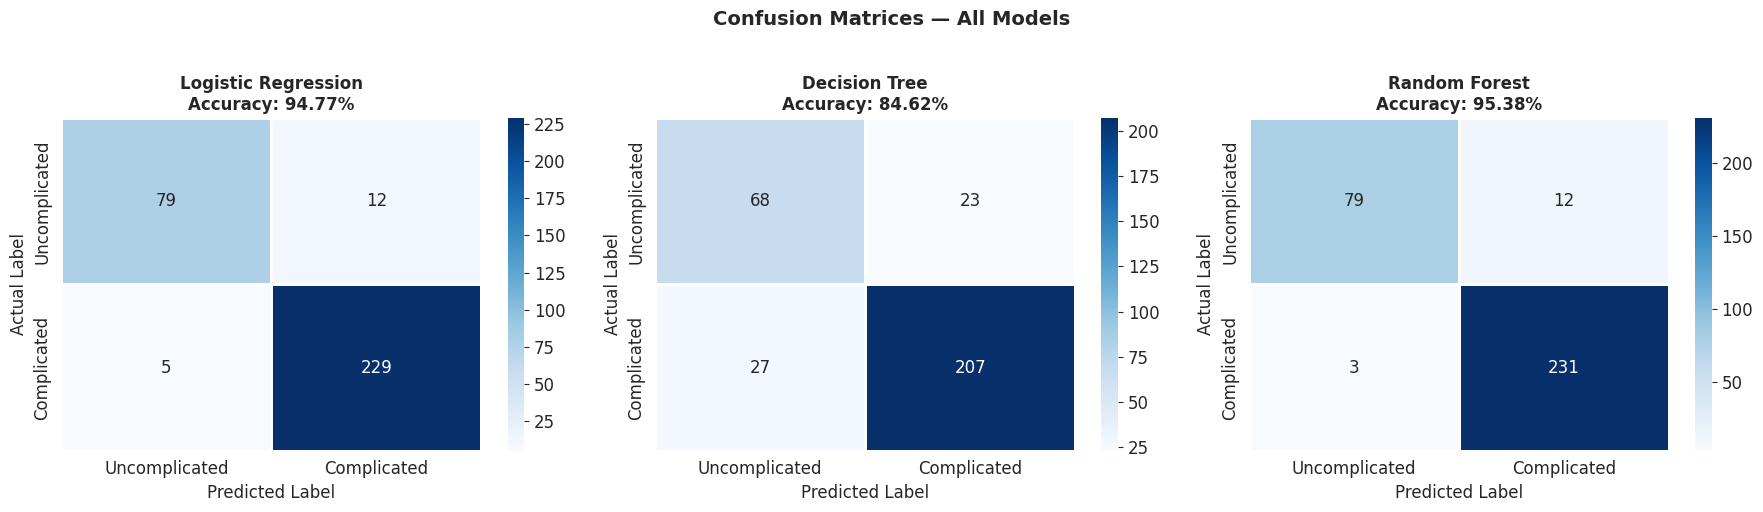

 Chart saved as 'fig6_confusion_matrices.png'


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Uncomplicated', 'Complicated']

for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels,
                linewidths=1, linecolor='white')
    ax.set_title(f'{name}\nAccuracy: {r["Accuracy"]:.2%}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as 'fig6_confusion_matrices.png'")

##ROC Curves

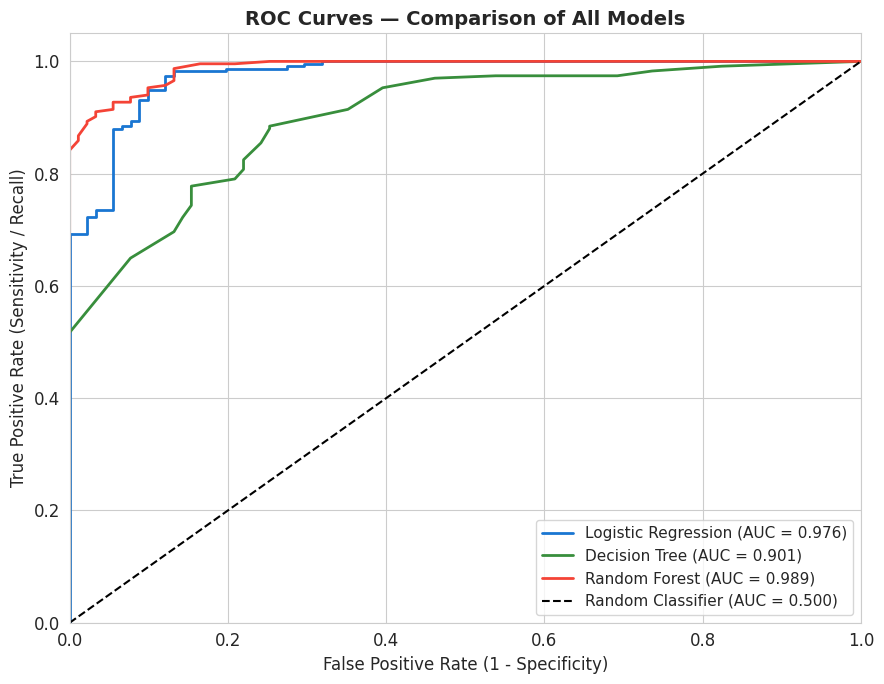

 Chart saved as 'fig7_roc_curves.png'


In [38]:
plt.figure(figsize=(9, 7))
colors_roc = ['#1976D2', '#388E3C', '#F44336']

for (name, r), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {r["AUC-ROC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curves — Comparison of All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.savefig('fig7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as 'fig7_roc_curves.png'")

##Model comparison

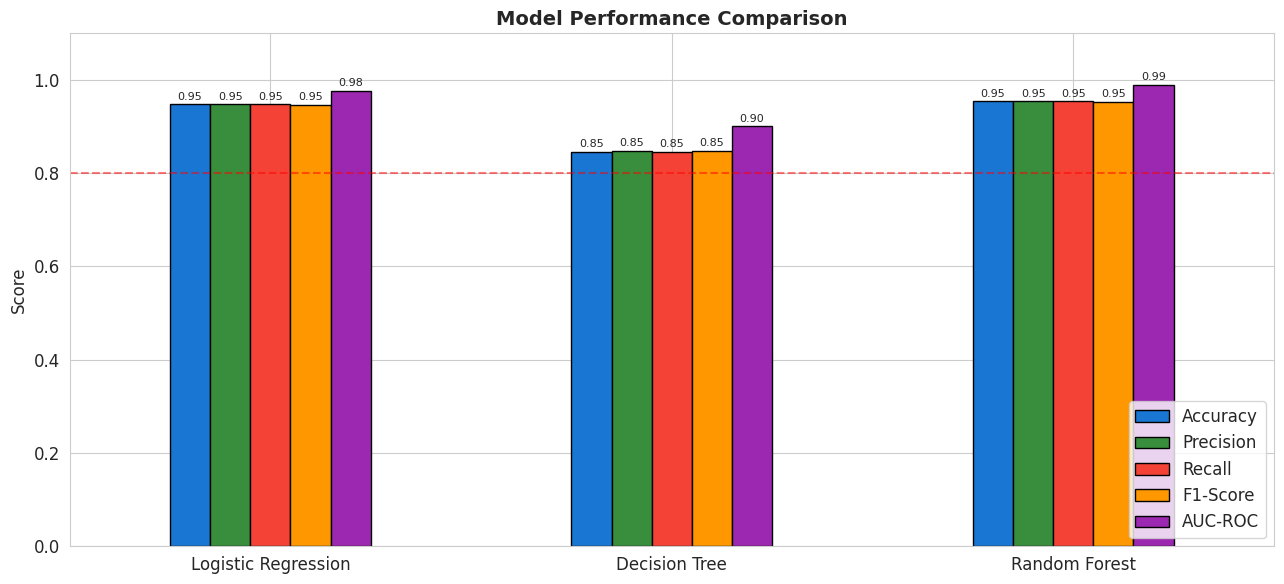

 Chart saved as 'fig8_model_comparison.png'


In [39]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy':  r['Accuracy'],
        'Precision': r['Precision'],
        'Recall':    r['Recall'],
        'F1-Score':  r['F1-Score'],
        'AUC-ROC':   r['AUC-ROC']
    }
    for name, r in results.items()
}).T

metrics_df.plot(kind='bar', figsize=(13, 6), edgecolor='black',
                color=['#1976D2', '#388E3C', '#F44336', '#FF9800', '#9C27B0'])
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.ylim([0, 1.1])
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.80 threshold')
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Chart saved as 'fig8_model_comparison.png'")

##Feature Importance

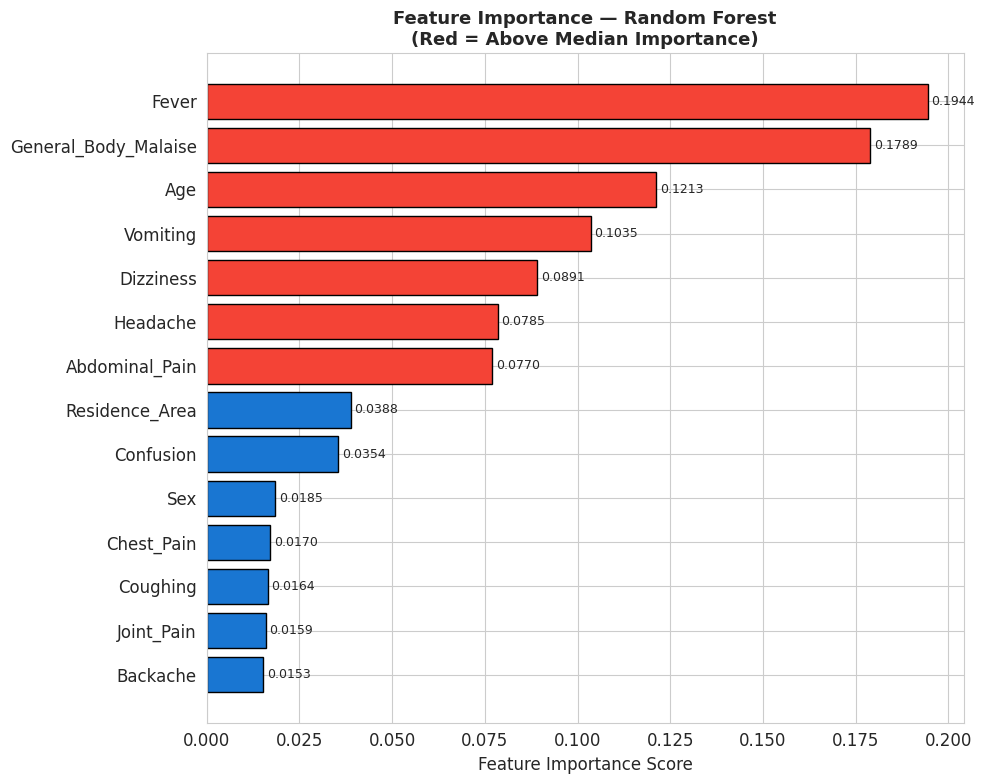


 Top 5 Most Important Features:
  1. Fever                     0.1944
  2. General_Body_Malaise      0.1789
  3. Age                       0.1213
  4. Vomiting                  0.1035
  5. Dizziness                 0.0891

 Chart saved as 'fig9_feature_importance.png'


In [40]:
#Random Forest Feature Importance

feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

# Horizontal bar chart
colors_fi = ['#F44336' if imp > feat_imp_df['Importance'].median() else '#1976D2'
             for imp in feat_imp_df['Importance']]

plt.figure(figsize=(10, 8))
bars = plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
                color=colors_fi, edgecolor='black')
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Feature Importance — Random Forest\n(Red = Above Median Importance)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, feat_imp_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Top 5 Most Important Features:")
top5 = feat_imp_df.sort_values('Importance', ascending=False).head(5)
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  {i}. {row['Feature']:<25} {row['Importance']:.4f}")

print("\n Chart saved as 'fig9_feature_importance.png'")

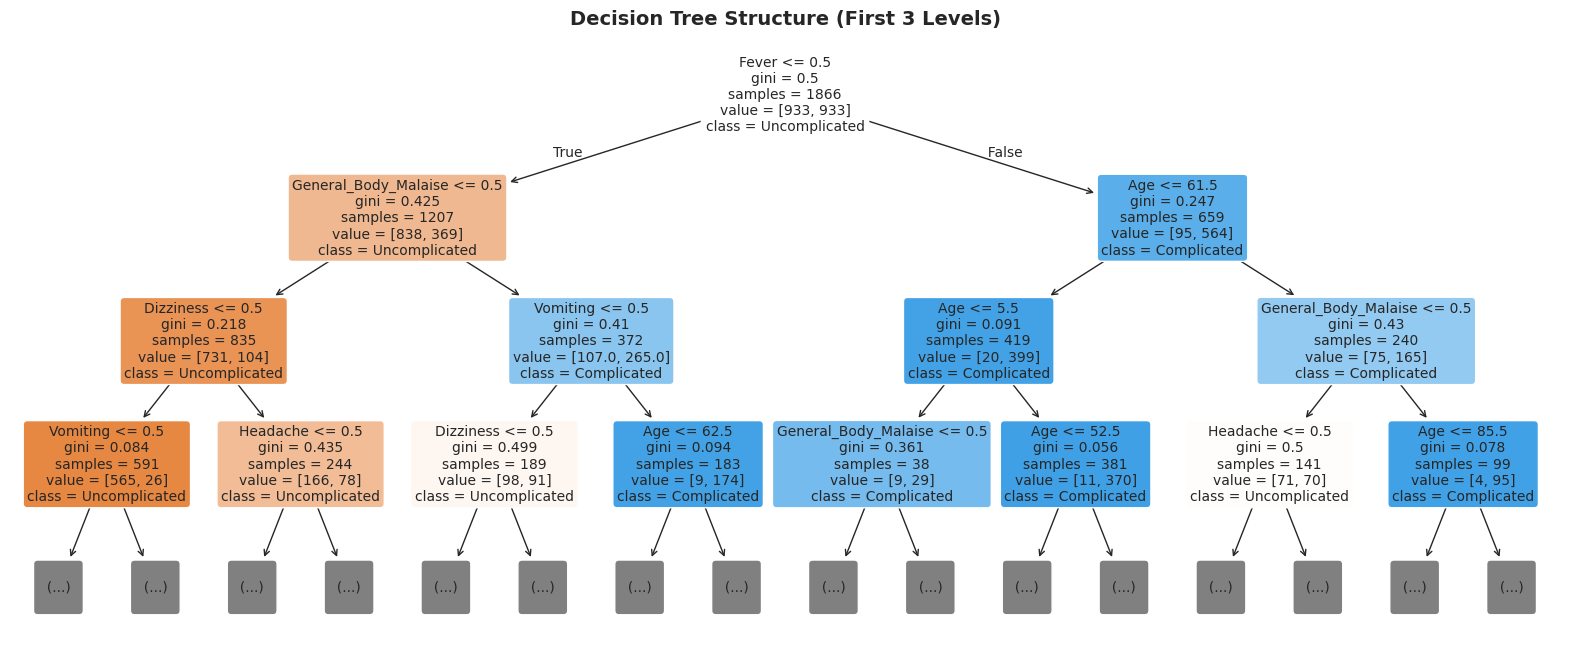

 Chart saved as 'fig10_decision_tree.png'


In [41]:
# Visualise the Decision Tree (first 3 levels)
# This shows the logical rules the tree learned
plt.figure(figsize=(20, 8))
plot_tree(dt_model, max_depth=3,
          feature_names=feature_names,
          class_names=['Uncomplicated', 'Complicated'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Structure (First 3 Levels)', fontsize=14, fontweight='bold')
plt.savefig('fig10_decision_tree.png', dpi=100, bbox_inches='tight')
plt.show()
print(" Chart saved as 'fig10_decision_tree.png'")

In [42]:
#Cross-validation (more reliable accuracy estimate)
# Tests the model on 5 different splits of the data
# Gives a fairer estimate of true performance
print(" Running 5-Fold Cross-Validation...\n")

cv_models = {
    'Logistic Regression': lr_model,
    'Decision Tree':       dt_model,
    'Random Forest':       rf_model
}

cv_data    = X_train_balanced
cv_labels  = y_train_balanced

print(f"{'Model':<25} {'Mean CV Accuracy':>18} {'Std Dev':>10}")
print("-" * 56)
for name, model in cv_models.items():
    X_cv = scaler.transform(cv_data) if name == 'Logistic Regression' else cv_data
    cv_scores = cross_val_score(model, X_cv, cv_labels, cv=5, scoring='accuracy')
    print(f"{name:<25} {cv_scores.mean():>18.4f} {cv_scores.std():>10.4f}")

print("\n Lower std dev = more consistent performance across folds")

 Running 5-Fold Cross-Validation...

Model                       Mean CV Accuracy    Std Dev
--------------------------------------------------------
Logistic Regression                   0.9603     0.0205
Decision Tree                         0.8966     0.0489
Random Forest                         0.9673     0.0312

 Lower std dev = more consistent performance across folds


#A Prediction on a New Patient

In [45]:
new_patient = {
    'Age':                  35,   # Patient age in years
    'Sex':                   1,   # 0=Female, 1=Male
    'Residence_Area':        2,   # 0-4 as shown above
    'Fever':                 1,   # 1=Yes, 0=No
    'Headache':              1,
    'Abdominal_Pain':        0,
    'General_Body_Malaise':  1,
    'Dizziness':             1,
    'Vomiting':              1,
    'Confusion':             0,
    'Backache':              0,
    'Chest_Pain':            0,
    'Coughing':              1,
    'Joint_Pain':            0
}

# Convert to DataFrame so models can read it
patient_df = pd.DataFrame([new_patient])

# Make predictions with all three models
print(" Predicting for new patient...")
print("="*45)

for name, (model, _) in models.items():
    X_input = scaler.transform(patient_df) if name == 'Logistic Regression' else patient_df
    prediction = model.predict(X_input)[0]
    probability = model.predict_proba(X_input)[0][1] * 100
    outcome = '  COMPLICATED MALARIA' if prediction == 1 else ' UNCOMPLICATED MALARIA'
    print(f"\n{name}:")
    print(f"  Prediction:  {outcome}")
    print(f"  Probability of complication: {probability:.1f}%")

print("\n" + "="*45)

 Predicting for new patient...

Logistic Regression:
  Prediction:    COMPLICATED MALARIA
  Probability of complication: 100.0%

Decision Tree:
  Prediction:    COMPLICATED MALARIA
  Probability of complication: 100.0%

Random Forest:
  Prediction:    COMPLICATED MALARIA
  Probability of complication: 100.0%

